# CNN

## MNIST

setosa.io/ev/image-kernekls/

MNIST Data Set
(60000,28, 28,1) --> (60000,10) test 
image = [0,43,5,3,5...] --> One hot transformation to create the output


In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
single_image = x_train[0]

In [6]:
x_train[0].shape

(28, 28)

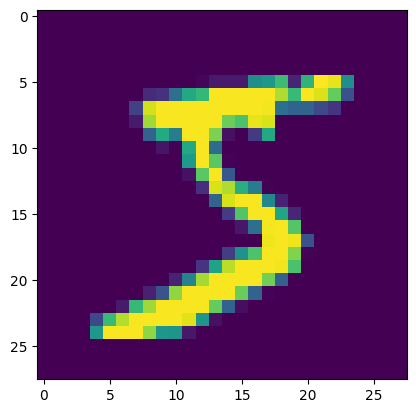

In [7]:
plt.imshow(single_image) # Gray Scale Using Viridis Only 2 colors

In [8]:
y_train # Continuos values  not, convert to a category

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [9]:
y_example = to_categorical(y_train) # One hot Encoding

In [10]:
y_example

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [11]:
y_example.shape

(60000, 10)

In [12]:
y_example[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [13]:
y_cat_test = to_categorical(y_test,num_classes = 10)

In [14]:
y_cat_train = to_categorical(y_train,10)

In [15]:
single_image.max()

255

In [16]:
single_image.min()

0

In [17]:
x_train = x_train/255
x_test = x_test/255

In [18]:
x_train.shape # We have to add color channel

(60000, 28, 28)

In [19]:
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)

### Training the model

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [21]:
model = Sequential()

# CONVOLUTIONAL LAYER
# filters = 2^n, 
model.add(Conv2D(filters=32, kernel_size=(4,4),input_shape=(28, 28, 1), activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

# FLATTEN IMAGES FROM 28 by 28 to 764 BEFORE FINAL LAYER
model.add(Flatten())

# 128 NEURONS IN DENSE HIDDEN LAYER (YOU CAN CHANGE THIS NUMBER OF NEURONS)
model.add(Dense(128, activation='relu'))

# LAST LAYER IS THE CLASSIFIER, THUS 10 POSSIBLE CLASSES
model.add(Dense(10, activation='softmax'))

# https://keras.io/metrics/
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']) # we can add in additional metrics https://keras.io/metrics/

C:\Users\Pedro Delgado Jiméne\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=2)

In [23]:
model.fit(x_train,y_cat_train,epochs=10,validation_data=(x_test,y_cat_test),callbacks=[early_stop])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - accuracy: 0.9131 - loss: 0.2921 - val_accuracy: 0.9815 - val_loss: 0.0571
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9847 - loss: 0.0507 - val_accuracy: 0.9814 - val_loss: 0.0560
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9899 - loss: 0.0317 - val_accuracy: 0.9882 - val_loss: 0.0357
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9878 - val_loss: 0.0371
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9963 - loss: 0.0123 - val_accuracy: 0.9877 - val_loss: 0.0358


In [24]:
metrics = pd.DataFrame(model.history.history)

<Axes: >

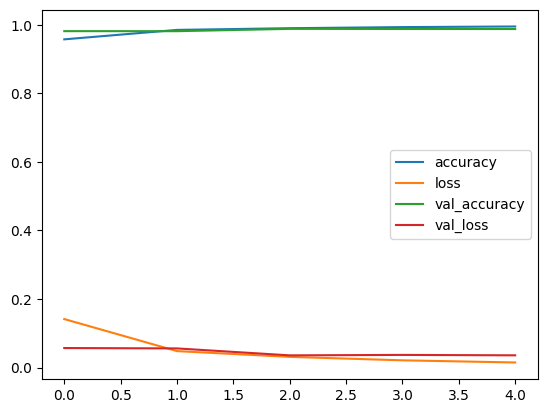

In [25]:
metrics.plot()

<Axes: >

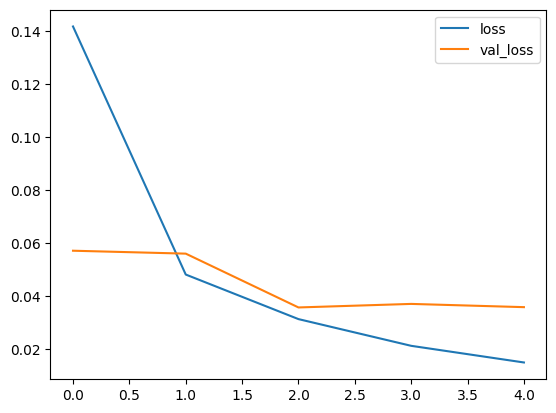

In [26]:
metrics[['loss','val_loss']].plot()

<Axes: >

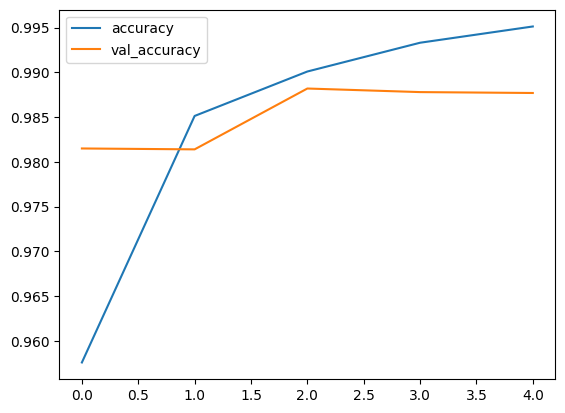

In [27]:
metrics[['accuracy','val_accuracy']].plot()

In [28]:
model.metrics_names

['loss', 'compile_metrics']

In [29]:
model.evaluate(x_test,y_cat_test,verbose=0)

[0.03583335503935814, 0.9876999855041504]

In [30]:
from sklearn.metrics import classification_report,confusion_matrix

In [31]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [32]:
def pred(predictions):
    
    return [np.argmax(i) for i in predictions]

predictions_classes = pred(predictions)

In [33]:
print(classification_report(y_test,predictions_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [34]:
confusion_matrix(y_test,predictions_classes)

array([[ 974,    1,    1,    0,    0,    0,    2,    1,    1,    0],
       [   0, 1132,    0,    0,    0,    0,    2,    1,    0,    0],
       [   0,    0, 1021,    0,    1,    0,    1,    6,    3,    0],
       [   0,    1,    2,  991,    0,   10,    0,    3,    1,    2],
       [   0,    0,    0,    0,  974,    0,    3,    0,    0,    5],
       [   2,    0,    0,    2,    0,  885,    1,    0,    2,    0],
       [   2,    2,    0,    0,    1,    2,  951,    0,    0,    0],
       [   0,    2,    7,    0,    1,    0,    0, 1016,    1,    1],
       [   5,    0,    4,    1,    0,    1,    2,    4,  954,    3],
       [   1,    1,    0,    1,   11,    5,    0,    8,    3,  979]],
      dtype=int64)

In [35]:
import seaborn as sns

<Axes: >

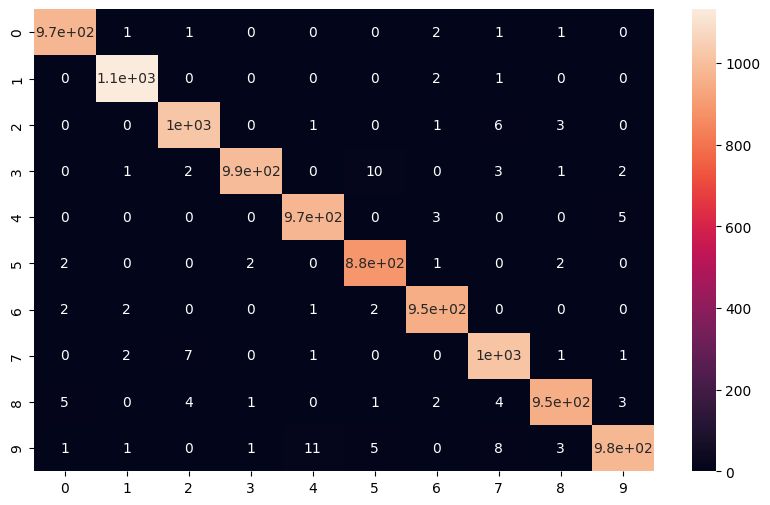

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,predictions_classes),annot=True)

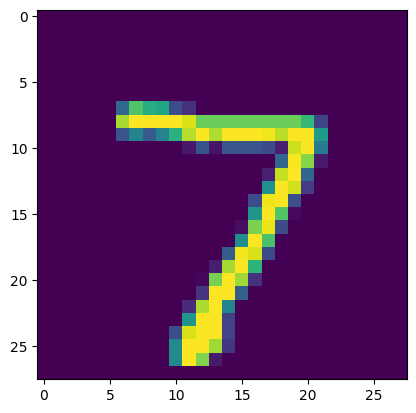

In [37]:
my_number = x_test[0]
plt.imshow(my_number.reshape(28,28))

In [38]:
# SHAPE --> (num_images,width,height,color_channels)
pred(model.predict(my_number.reshape(1,28,28,1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


[7]

## CIFAR10

In [39]:
import pandas as pd
import numpy as np

## Cell_images.zip

In [40]:
import os

In [41]:
os.listdir('Esquema_Data_Science/TensorFlow/TF_2_Notebooks_and_Data/04-CNNs/cell_images/')

['test', 'train']

In [42]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread
# Technically not necessary in newest versions of jupyter
%matplotlib inline

In [43]:
my_data_dir = 'Esquema_Data_Science/TensorFlow/TF_2_Notebooks_and_Data/04-CNNs/cell_images/'
os.listdir(my_data_dir) 

['test', 'train']

In [44]:
test_path = my_data_dir+'\\test\\'
train_path = my_data_dir+'\\train\\'
os.listdir(test_path)
os.listdir(train_path)

['parasitized', 'uninfected']

In [45]:
os.listdir(train_path+'\\parasitized')[0]

'C100P61ThinF_IMG_20150918_144104_cell_162.png'

(148, 142, 3)

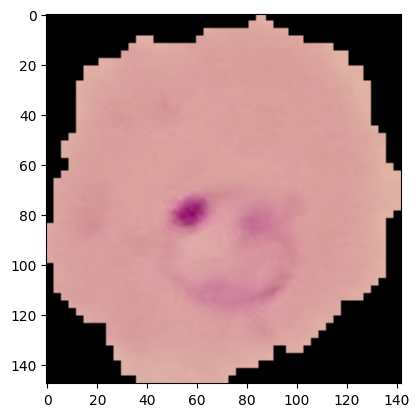

In [46]:
para_cell = train_path+'\\parasitized'+'\\C100P61ThinF_IMG_20150918_144104_cell_162.png'
para_img= imread(para_cell)
plt.imshow(para_img)
para_img.shape

(139, 160, 3)

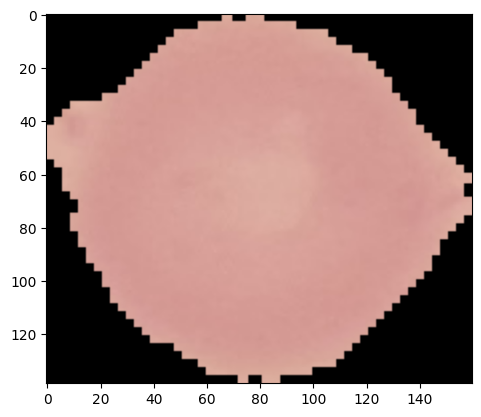

In [47]:
unifected_cell_path = train_path+'\\uninfected\\'+os.listdir(train_path+'\\uninfected')[0]
unifected_cell = imread(unifected_cell_path)
plt.imshow(unifected_cell)
unifected_cell.shape

In [48]:
print(len(os.listdir(train_path+'\\parasitized')))
print(len(os.listdir(train_path+'\\uninfected')))

12480
12480


In [49]:
# Distintas dimensiones entre los datos de infectados/No infectados
dim1 = []
dim2 = []

for image_file in os.listdir(test_path+'\\uninfected'):

    img = imread(test_path+'uninfected\\' +image_file)
    d1, d2, colors = img.shape
    dim1.append(d1)
    dim2.append(d2)

In [50]:
dim1[:3]

[118, 172, 130]

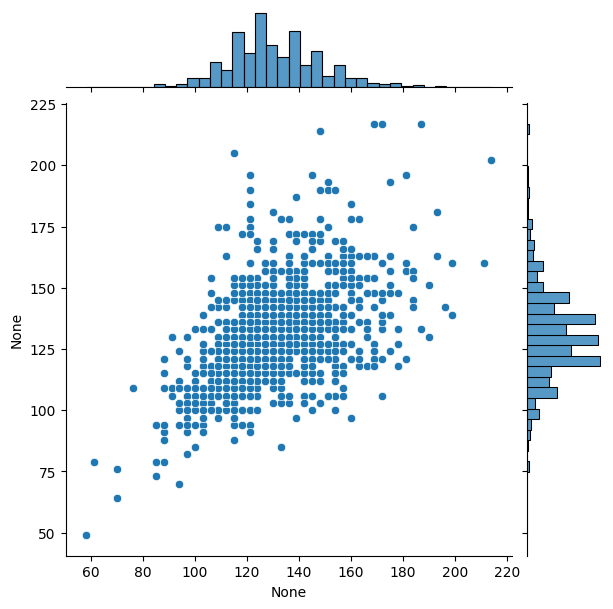

In [51]:
sns.jointplot(x=dim1, y = dim2)

In [52]:
# Resize with the average
np.mean(dim1) # 130
np.mean(dim2) 
image_shape = (130,130,3) # 130*130*3 = 50700
# We have to reduce, make batchs

### Create more data for our train

In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [54]:
help(ImageDataGenerator)

Help on class ImageDataGenerator in module keras.src.legacy.preprocessing.image:

class ImageDataGenerator(builtins.object)
 |  ImageDataGenerator(featurewise_center=False, samplewise_center=False, featurewise_std_normalization=False, samplewise_std_normalization=False, zca_whitening=False, zca_epsilon=1e-06, rotation_range=0, width_shift_range=0.0, height_shift_range=0.0, brightness_range=None, shear_range=0.0, zoom_range=0.0, channel_shift_range=0.0, fill_mode='nearest', cval=0.0, horizontal_flip=False, vertical_flip=False, rescale=None, preprocessing_function=None, data_format=None, validation_split=0.0, interpolation_order=1, dtype=None)
 |
 |  DEPRECATED.
 |
 |  Methods defined here:
 |
 |  __init__(self, featurewise_center=False, samplewise_center=False, featurewise_std_normalization=False, samplewise_std_normalization=False, zca_whitening=False, zca_epsilon=1e-06, rotation_range=0, width_shift_range=0.0, height_shift_range=0.0, brightness_range=None, shear_range=0.0, zoom_range=

In [64]:
imread(para_cell).max() # We dont have to reescale

0.9098039

In [107]:
image_gen = ImageDataGenerator(rotation_range = 360, 
                              width_shift_range = 0.5, # Depends kind of images
                              height_shift_range = 0.5,
                              #rescale = 1/max)
                               shear_range = 0.1,
                               zoom_range = 0.5,
                               horizontal_flip = True,
                               fill_mode = 'nearest')                    

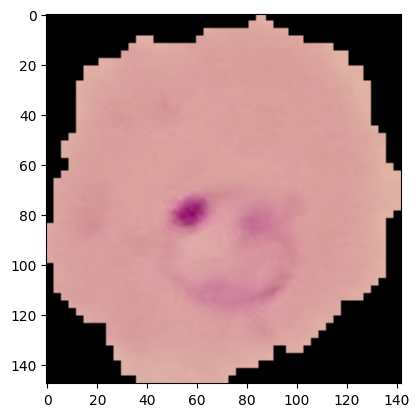

In [69]:
para_img = imread(para_cell)
plt.imshow(para_img)

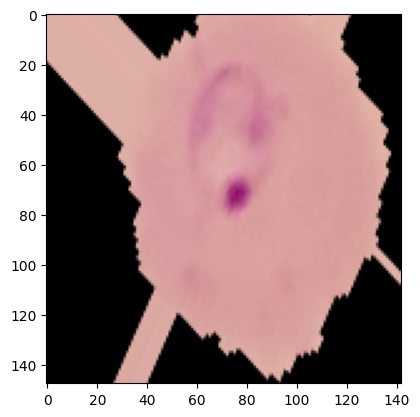

In [108]:
plt.imshow(image_gen.random_transform(para_img)) # To have more data examples to train

#### Directory Structure

In [109]:
image_gen.flow_from_directory(train_path) # Specific way folder for each class.

Found 24958 images belonging to 2 classes.


In [110]:
image_gen.flow_from_directory(test_path)

Found 2600 images belonging to 2 classes.


#### Model

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [111]:
#https://stats.stackexchange.com/questions/148139/rules-for-selecting-convolutional-neural-network-hyperparameters
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3,3),input_shape=image_shape, activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Flatten())


model.add(Dense(256, activation = 'relu'))
# model.add(Activation('relu'))

# Dropouts help reduce overfitting by randomly turning neurons off during training.
# Here we say randomly turn off 50% of neurons.
model.add(Dropout(0.5))

# Last layer, remember its binary so we use sigmoid
model.add(Dense(1, activation = 'sigmoid'))
# model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [101]:
from tensorflow.keras.callbacks import EarlyStopping

In [112]:
early_stop = EarlyStopping(monitor='val_loss',patience=2)

In [113]:
batch_size = 16 # 2^n

In [114]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=image_shape[:2],
                                                color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary')

Found 24958 images belonging to 2 classes.


In [115]:
test_image_gen = image_gen.flow_from_directory(test_path,
                                               target_size=image_shape[:2],
                                                color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary',
                                              shuffle = False) # Only in training

Found 2600 images belonging to 2 classes.


In [116]:
results = model.fit(train_image_gen, epochs = 20, validation_data = test_image_gen,
                              callbacks = [early_stop])


Epoch 1/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 512s 320ms/step - accuracy: 0.5131 - loss: 1.0239 - val_accuracy: 0.5073 - val_loss: 0.6932
Epoch 2/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 111s 71ms/step - accuracy: 0.5179 - loss: 0.6936 - val_accuracy: 0.5058 - val_loss: 0.6932
Epoch 3/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 115s 74ms/step - accuracy: 0.5283 - loss: 0.6922 - val_accuracy: 0.5377 - val_loss: 0.6898
Epoch 4/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 119s 76ms/step - accuracy: 0.5468 - loss: 0.6881 - val_accuracy: 0.5404 - val_loss: 0.6934
Epoch 5/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 114s 73ms/step - accuracy: 0.6021 - loss: 0.6428 - val_accuracy: 0.7927 - val_loss: 0.4463
Epoch 6/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 112s 72ms/step - accuracy: 0.8114 - loss: 0.4359 - val_accuracy: 0.8258 - val_loss: 0.4455
Epoch 7/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 116s 74ms/step - accuracy: 0.8264 - loss: 0.4080 - val_accuracy: 0.8208 - val_loss: 0.4243
Epoch 8/20
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy:

In [82]:
def pred(predictions):
    
    return [np.argmax(i) for i in predictions]

#predictions_classes = pred(predictions)

In [118]:
# Cargar el modelo
from tensorflow.keras.models import load_model
model = load_model('Esquema_Data_Science/TensorFlow/TF_2_Notebooks_and_Data/04-CNNs/malaria_detector.h5')

ValueError: Kernel shape must have the same length as input, but received kernel of shape (3, 3, 3, 32) and input of shape (None, None, 130, 130, 3).

In [ ]:
model.summary()

In [127]:
losses = pd.DataFrame(model.history.history) # Dont exist if you load the model
losses.columns

Index(['accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')

<Axes: >

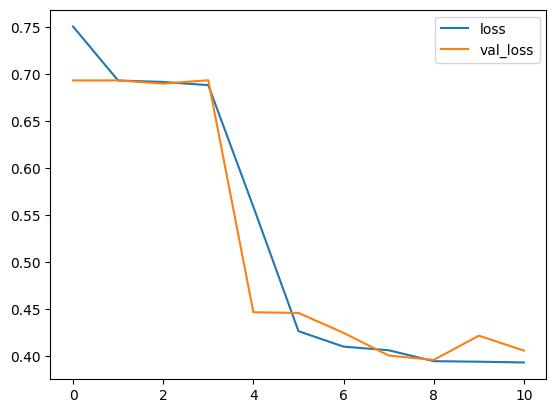

In [126]:
losses[['loss','val_loss']].plot()

<Axes: >

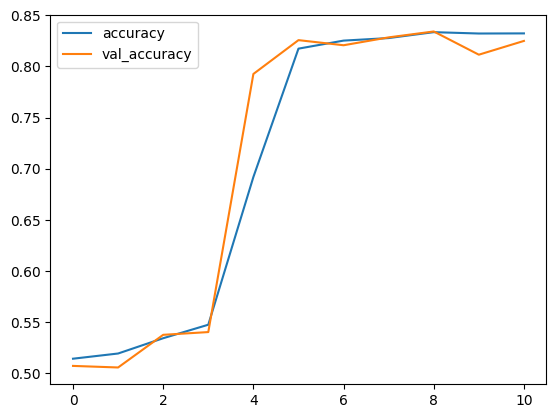

In [129]:
losses[['accuracy','val_accuracy']].plot()

In [131]:
model.evaluate(test_image_gen)

163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.7622 - loss: 0.4000


[0.398005872964859, 0.8296154141426086]

In [132]:
model.metrics_names

['loss', 'compile_metrics']

In [133]:
pred = model.predict(test_image_gen)

163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step


In [135]:
pred

array([[6.9027923e-02],
       [1.2082307e-06],
       [7.4321200e-05],
       ...,
       [7.4662209e-01],
       [7.4662209e-01],
       [7.9189050e-01]], dtype=float32)

In [136]:
predictions = pred > 0.5 

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [137]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1300
           1       0.78      0.93      0.85      1300

    accuracy                           0.84      2600
   macro avg       0.85      0.84      0.83      2600
weighted avg       0.85      0.84      0.83      2600



In [138]:
confusion_matrix(test_image_gen.classes, predictions)

array([[ 960,  340],
       [  88, 1212]], dtype=int64)

In [142]:
from tensorflow.keras.preprocessing import image

In [159]:
my_image = image.load_img(para_cell, target_size = image_shape) # you can reshape

In [160]:
my_image_arr = image.img_to_array(my_image)
my_image_arr.shape

(130, 130, 3)

In [162]:
my_image_arr = np.expand_dims(my_image_arr, axis = 0) # Needs the model the size  (1,130,130,3)
my_image_arr.shape

(1, 130, 130, 3)

In [163]:
model.predict(my_image_arr).round()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[0.]], dtype=float32)

In [156]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}